> Comment: Introduces the notebook scope and the exploration objectives.

# Steriflow MPI1 Data Exploration

Notebook goals:
- Read all `.txt` files from the MPI1 export folder.
- Sort files by modification date.
- Ignore lines 1 to 10.
- Use line 11 as headers and line 12 as active/inactive flags.
- Keep datetime found in square brackets in filename as `batch_datetime`.
- Merge files with and without `_II` suffix for the same batch.
- Build a combined dataframe and plot time series for exploration.


In [1]:
# Cell comment: Import libraries, configure display/plot settings, and define the input data folder.
# Setup
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)

DATA_DIR = Path(
    r"D:\\Cascadya\\Cascadya - Documents\\08. COMPTE CLIENT\\Inariz_Lamballe\\2. Données sous NDA\\données Steriflow\\MPI1_csv"
)
DATA_DIR

WindowsPath('D:/Cascadya/Cascadya - Documents/08. COMPTE CLIENT/Inariz_Lamballe/2. Données sous NDA/données Steriflow/MPI1_csv')

> Comment: Summarizes the parsing and merge rules implemented in helper functions.

## Helpers for parsing and merging

Rules implemented exactly as requested:
- sort files by modification datetime,
- line 11 = headers,
- line 12 = active/inactive flags,
- load all columns,
- merge base and `_II` companion files for the same batch datetime.


In [ ]:
# Cell comment: Define helper functions to parse files, extract metadata, convert data types, and merge base/_II variants.
FILENAME_DT_RE = re.compile(r"\[(\d{2}_\d{2}_\d{4}_\d{2}_\d{2}_\d{2})\]")


def parse_batch_datetime(file_path: Path) -> pd.Timestamp | pd.NaT:
    match = FILENAME_DT_RE.search(file_path.name)
    if not match:
        return pd.NaT
    return pd.to_datetime(match.group(1), format="%d_%m_%Y_%H_%M_%S", errors="coerce")


def normalize_batch_key(file_path: Path) -> str:
    stem = file_path.stem
    if stem.endswith("_II"):
        stem = stem[:-3]
    return stem


def suffix_type(file_path: Path) -> str:
    return "II" if file_path.stem.endswith("_II") else "base"


def make_unique_headers(raw_headers: list[str]) -> list[str]:
    headers: list[str] = []
    seen: dict[str, int] = {}
    for idx, h in enumerate(raw_headers):
        clean = h.strip()
        if clean == "":
            clean = f"_unnamed_{idx}"
        count = seen.get(clean, 0)
        seen[clean] = count + 1
        headers.append(clean if count == 0 else f"{clean}_{count + 1}")
    return headers


def read_steriflow_txt(file_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    lines = file_path.read_text(encoding="utf-16", errors="replace").splitlines()
    if len(lines) < 12:
        raise ValueError(f"File has fewer than 12 lines: {file_path}")

    header_line = lines[10]
    # active_line = lines[11]
    data_lines = lines[12:]

    raw_headers = [c.strip() for c in header_line.split(";")]
    # active_flags = [c.strip() for c in active_line.split(";")]
    headers = make_unique_headers(raw_headers)

    n_cols = len(headers)

    rows: list[list[str]] = []
    for line in data_lines:
        if not line.strip():
            continue
        values = line.split(";")
        if len(values) < n_cols:
            values += [""] * (n_cols - len(values))
        elif len(values) > n_cols:
            values = values[:n_cols]
        rows.append(values)

    df = pd.DataFrame(rows, columns=headers)

    df = df[df.columns.drop(list(df.filter(regex="unnamed")))]

    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()

    dt = parse_batch_datetime(file_path)
    df["batch_datetime"] = dt
    df["batch_key"] = normalize_batch_key(file_path)
    df["file_variant"] = suffix_type(file_path)
    df["source_file"] = file_path.name
    df["file_mtime"] = pd.to_datetime(file_path.stat().st_mtime, unit="s")

    # active_flags += [""] * (n_cols - len(active_flags))
    # activity = pd.DataFrame(
    #     {
    #         "column": headers,
    #         "active_flag": active_flags[:n_cols],
    #         "source_file": file_path.name,
    #         "file_variant": suffix_type(file_path),
    #         "batch_datetime": dt,
    #         "batch_key": normalize_batch_key(file_path),
    #     }
    # )

    return df  # , activity


def to_numeric_best_effort(df: pd.DataFrame, skip: set[str]) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if col in skip:
            continue
        if out[col].dtype == object:
            cleaned = out[col].str.replace(",", ".", regex=False)
            num = pd.to_numeric(cleaned, errors="coerce")
            if num.notna().sum() > 0:
                out[col] = num
    return out


# merge on instant
# filter on batch_datetime, batch_key, variant (1 de chaque),
def merge_frames(parsed_frames: list) -> pd.DataFrame:
    # sort the frames
    dict_before_merge: dict[str, dict] = {}
    for frame in parsed_frames:
        if frame["batch_datetime"].unique()[0] not in dict_before_merge.keys():
            dict_before_merge[frame["batch_datetime"].unique()[0]] = {}

        if frame["file_variant"].unique()[0] == "base":
            dict_before_merge[frame["batch_datetime"].unique()[0]]["base"] = (
                frame.copy()
            )
        elif frame["file_variant"].unique()[0] == "II":
            dict_before_merge[frame["batch_datetime"].unique()[0]]["II"] = frame.copy()

    # merge twin frames
    list_merged_frames: list[pd.DataFrame] = []
    merge_keys = ["Instant", "Phase", "batch_datetime", "batch_key"]

    for dict_inside in dict_before_merge.values():
        if "base" not in dict_inside.keys():
            list_merged_frames.append(dict_inside["II"])
        elif "II" not in dict_inside.keys():
            list_merged_frames.append(dict_inside["base"])
        else:
            drop_meta = {"file_variant", "source_file", "file_mtime"}
            base_data = dict_inside["base"].drop(
                columns=[c for c in drop_meta if c in dict_inside["base"].columns]
            )
            ii_data = dict_inside["II"].drop(
                columns=[c for c in drop_meta if c in dict_inside["II"].columns]
            )

            merged = base_data.merge(
                ii_data, on=merge_keys, how="outer", suffixes=("_base", "_ii")
            )
            # I do not expect to see columns columns with suffix
            merged["source_file"] = "; ".join(
                sorted(
                    (
                        dict_inside["base"]["source_file"].unique()[0],
                        dict_inside["II"]["source_file"].unique()[0],
                    )
                )
            )
            merged["file_mtime"] = max(
                dict_inside["base"]["file_mtime"].unique()[0],
                dict_inside["II"]["file_mtime"].unique()[0],
            )
            merged["file_variant"] = "merged"

            list_merged_frames.append(merged)

    # concat everything
    return pd.concat(list_merged_frames, ignore_index=True)

> Comment: Describes the outputs produced by the data loading and merge workflow.

## Load all files and combine base + `_II`

This cell outputs:
- `df_all_raw`: concatenation of every parsed file,
- `df_all`: merged per batch key/date with numeric conversion,
- `activity_flags`: line-12 active/inactive info for every source file.


In [3]:
# Cell comment: Discover and parse all text files sorted by modification date, then collect raw frames.
txt_files = sorted(DATA_DIR.glob("*.txt"), key=lambda p: p.stat().st_mtime)
if not txt_files:
    raise FileNotFoundError(f"No .txt files found in {DATA_DIR}")

parsed_frames: list[pd.DataFrame] = []
# activity_frames: list[pd.DataFrame] = []

for path in txt_files:
    df_file = read_steriflow_txt(path)  # df_file, df_activity
    parsed_frames.append(df_file)
    # activity_frames.append(df_activity)

# activity_flags = pd.concat(activity_frames, ignore_index=True)

In [4]:
df_all = merge_frames(parsed_frames)

meta_cols = {
    "Instant",
    "Phase",
    "batch_datetime",
    "batch_key",
    "file_variant",
    "source_file",
    "file_mtime",
}
df_all = to_numeric_best_effort(df_all, skip=meta_cols)

In [5]:
# Cell comment: Convert values, sort the final dataset, and display first results.

# Add the date from batch_datetime, for a complete timestamp.
# Ca va, jusqu'a présent on a seulement sort par les métadata.
df_all["Timestamp"] = pd.to_datetime(
    df_all["batch_datetime"].dt.date.astype(str) + " " + df_all["Instant"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce",
)


# si l'instant est plus tot que le time du batch_datetime, incrémenter la date et le timestamp de 1
mask_to_increment = df_all["Instant"] < df_all["batch_datetime"].dt.time.astype(str)
df_all.loc[mask_to_increment, "Timestamp"] = df_all.loc[
    mask_to_increment, "Timestamp"
] + pd.Timedelta(days=1)

df_all = df_all.sort_values(["Timestamp"], na_position="last").reset_index(drop=True)

print(f"Files read: {len(txt_files)}")
print(f"Rows in raw concatenation: {sum(len(frame) for frame in parsed_frames):,}")
print(f"Rows after base/_II merge: {len(df_all):,}")
display(df_all.head(5))
# display(activity_flags.head(10))

Files read: 378
Rows in raw concatenation: 25,794
Rows after base/_II merge: 12,897


,Instant,Phase,Consigne (°C),Mesure Regul. (°C),Consigne (Bar),Mesure (Bar),T. Pt Froid (°C),T. Pt Froid 2 (°C),Niveau (cm),T. Ballast (°C),Vitesse (Tr/min),Débit (m3/h),Déflexion (mm),batch_datetime,batch_key,Mesure 1 Regul. (°C),Mesure 2 Regul. (°C),Mesure 1 (Bar),Mesure 2 (Bar),D. Pied Av. (mm),D. Pied Ar. (mm),Vol. Eau (l/h),Puiss. Elec. (kW),P. Diff. Ppe (Bar),source_file,file_mtime,file_variant,Timestamp
0,19:00:01,0,0.00,33.03,0.00,0.01,25.34,0.0,21.88,0.0,0.00,0.11,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,33.03,33.07,0.01,0.0,0.0,0.0,0.0,0.0,-0.02,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,2026-03-02 19:00:01
1,19:02:01,0,0.00,52.22,0.00,0.06,57.27,0.0,17.91,0.0,0.00,311.82,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,52.22,51.16,0.06,0.0,0.0,0.0,0.0,0.0,0.99,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,2026-03-02 19:02:01
2,19:04:01,1,54.95,54.02,0.04,0.04,51.77,0.0,19.32,0.0,0.98,395.79,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,54.02,53.96,0.04,0.0,0.0,0.0,0.0,0.0,1.03,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,2026-03-02 19:04:01
3,19:06:01,1,64.22,63.62,0.12,0.14,60.88,0.0,19.52,0.0,0.98,388.22,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,63.62,63.65,0.14,0.0,0.0,0.0,0.0,0.0,0.99,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,2026-03-02 19:06:01
4,19:08:01,1,73.49,71.81,0.18,0.19,69.78,0.0,20.53,0.0,0.98,392.98,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,71.81,71.75,0.19,0.0,0.0,0.0,0.0,0.0,1.03,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,2026-03-02 19:08:01


> Comment: Starts a quick quality-control section for dataset structure and coverage.

## Quick data quality checks

In [6]:
df_all.describe()

,Consigne (°C),Mesure Regul. (°C),Consigne (Bar),Mesure (Bar),T. Pt Froid (°C),T. Pt Froid 2 (°C),Niveau (cm),T. Ballast (°C),Vitesse (Tr/min),Débit (m3/h),Déflexion (mm),batch_datetime,Mesure 1 Regul. (°C),Mesure 2 Regul. (°C),Mesure 1 (Bar),Mesure 2 (Bar),D. Pied Av. (mm),D. Pied Ar. (mm),Vol. Eau (l/h),Puiss. Elec. (kW),P. Diff. Ppe (Bar),file_mtime,Timestamp
count,12897.000000,12897.000000,12897.000000,12897.000000,12897.000000,12897.0,12897.000000,12897.0,12897.000000,12897.000000,12897.0,12897,12897.000000,12897.000000,12897.000000,12897.0,12897.0,12897.0,12897.0,12897.0,12897.000000,12897,12897
mean,77.177106,81.249097,1.216764,1.225532,81.207946,0.0,18.101229,0.0,0.791400,359.730601,0.0,2026-03-17 11:08:33.227262208,81.249089,81.267717,1.225531,0.0,0.0,0.0,0.0,0.0,0.907178,2026-03-17 11:53:30.278731008,2026-03-17 12:00:59.056602368
min,0.000000,24.330000,0.000000,-0.010000,22.940000,0.0,2.730000,0.0,0.000000,0.110000,0.0,2026-03-02 18:58:01,24.330000,24.280000,-0.010000,0.0,0.0,0.0,0.0,0.0,-0.030000,2026-03-02 19:49:32.513788223,2026-03-02 19:00:01
25%,48.850000,53.520000,0.510000,0.520000,54.170000,0.0,16.090000,0.0,0.980000,392.370000,0.0,2026-03-10 14:44:01,53.520000,53.460000,0.520000,0.0,0.0,0.0,0.0,0.0,0.970000,2026-03-10 15:04:53.646565888,2026-03-10 16:00:01
50%,84.410000,85.410000,1.200000,1.210000,85.000000,0.0,18.330000,0.0,0.980000,394.570000,0.0,2026-03-18 16:31:24,85.410000,85.440000,1.210000,0.0,0.0,0.0,0.0,0.0,0.990000,2026-03-18 17:18:30.363262208,2026-03-18 18:12:24
75%,112.150000,112.100000,1.950000,1.960000,112.130000,0.0,20.560000,0.0,0.980000,395.910000,0.0,2026-03-25 05:10:01,112.100000,112.020000,1.960000,0.0,0.0,0.0,0.0,0.0,1.010000,2026-03-25 05:32:58.953023488,2026-03-25 06:06:30
max,125.000000,125.490000,2.800000,2.830000,125.240000,0.0,35.100000,0.0,2.000000,417.760000,0.0,2026-03-27 04:10:54,125.490000,125.410000,2.830000,0.0,0.0,0.0,0.0,0.0,1.100000,2026-03-27 04:53:59.609163284,2026-03-27 05:52:30
std,39.311679,33.065338,0.803845,0.797362,33.335534,0.0,3.742953,0.0,0.405661,110.784989,0.0,NaN,33.065328,33.089419,0.797364,0.0,0.0,0.0,0.0,0.0,0.283698,NaN,NaN


In [7]:
# Drop empty columns
empty_cols = [
    "Déflexion (mm)",
    "T. Pt Froid 2 (°C)",
    "T. Ballast (°C)",
    "Mesure 2 (Bar)",
    "D. Pied Av. (mm)",
    "D. Pied Ar. (mm)",
    "Vol. Eau (l/h)",
    "Puiss. Elec. (kW)",
]
df_all = df_all.drop(empty_cols, axis=1)


# Cell comment: Report dataset dimensions, batch coverage, numeric columns, and activity-flag distribution.
print("Columns:", len(df_all.columns))
print("Distinct batches:", df_all["batch_key"].nunique(dropna=False))
print("Batch datetime min/max:")
display(df_all["batch_datetime"].agg(["min", "max"]))

num_cols = [c for c in df_all.columns if pd.api.types.is_numeric_dtype(df_all[c])]
print(f"Numeric columns detected: {len(num_cols)}")
display(pd.Series(num_cols).head(20))

# activity_summary = (
#     activity_flags.assign(active_flag=lambda d: d["active_flag"].str.lower())
#     .groupby(["file_variant", "active_flag"], dropna=False)
#     .size()
#     .rename("count")
#     .reset_index()
# )
# display(activity_summary)

Columns: 20
Distinct batches: 189
Batch datetime min/max:


min   2026-03-02 18:58:01
max   2026-03-27 04:10:54
Name: batch_datetime, dtype: datetime64[ns]

Numeric columns detected: 12


0            Consigne (°C)
1       Mesure Regul. (°C)
2           Consigne (Bar)
3             Mesure (Bar)
4         T. Pt Froid (°C)
5              Niveau (cm)
6         Vitesse (Tr/min)
7             Débit (m3/h)
8     Mesure 1 Regul. (°C)
9     Mesure 2 Regul. (°C)
10          Mesure 1 (Bar)
11      P. Diff. Ppe (Bar)
dtype: object

> Comment: Introduces automated multi-series plotting for exploratory time-series analysis.

## Time series exploration plots

The notebook automatically picks the most populated numeric columns and plots them in small multiples.


In [8]:
# df_all["Timestamp"].min(), df_all["Timestamp"].max()

df_all[df_all["batch_datetime"] == "2026-03-02 23:34:09"]

# df_all["batch_datetime"].unique()

,Instant,Phase,Consigne (°C),Mesure Regul. (°C),Consigne (Bar),Mesure (Bar),T. Pt Froid (°C),Niveau (cm),Vitesse (Tr/min),Débit (m3/h),batch_datetime,batch_key,Mesure 1 Regul. (°C),Mesure 2 Regul. (°C),Mesure 1 (Bar),P. Diff. Ppe (Bar),source_file,file_mtime,file_variant,Timestamp
109,23:36:10,0,0.00,32.53,0.00,0.01,25.44,21.92,0.00,0.11,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,32.53,32.47,0.01,-0.02,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:36:10
110,23:38:10,0,0.00,48.42,0.00,0.05,56.17,20.50,0.00,271.91,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,48.42,47.06,0.05,1.00,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:38:10
111,23:40:10,1,54.84,53.92,0.04,0.04,51.77,14.00,0.00,388.34,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,53.92,53.96,0.04,1.00,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:40:10
112,23:42:10,1,64.11,63.32,0.11,0.15,60.48,14.03,0.00,400.30,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,63.32,63.35,0.15,1.03,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:42:10
113,23:44:10,1,73.39,72.31,0.18,0.19,69.48,15.34,0.00,399.45,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,72.31,72.35,0.19,0.99,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:44:10
114,23:46:10,2,79.75,78.11,0.30,0.30,76.09,14.85,0.00,393.22,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,78.11,78.04,0.30,0.96,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:46:10
115,23:48:10,2,87.82,85.91,0.44,0.47,84.00,15.78,0.00,393.35,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,85.91,85.84,0.47,1.02,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:48:10
116,23:50:10,2,95.00,93.80,0.58,0.62,91.91,15.50,0.00,392.98,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,93.80,93.83,0.62,1.01,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:50:10
117,23:52:10,3,96.09,96.00,0.72,0.71,95.01,19.28,0.97,396.03,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,96.00,96.03,0.71,0.98,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:52:10
118,23:54:10,3,97.45,97.50,0.81,0.78,96.71,19.09,0.98,393.83,2026-03-02 23:34:09,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,97.50,97.53,0.78,0.98,6_061_452_14_5_+_10_min_123°C_[02_03_2026_23_3...,2026-03-03 00:25:17.406102657,merged,2026-03-02 23:54:10


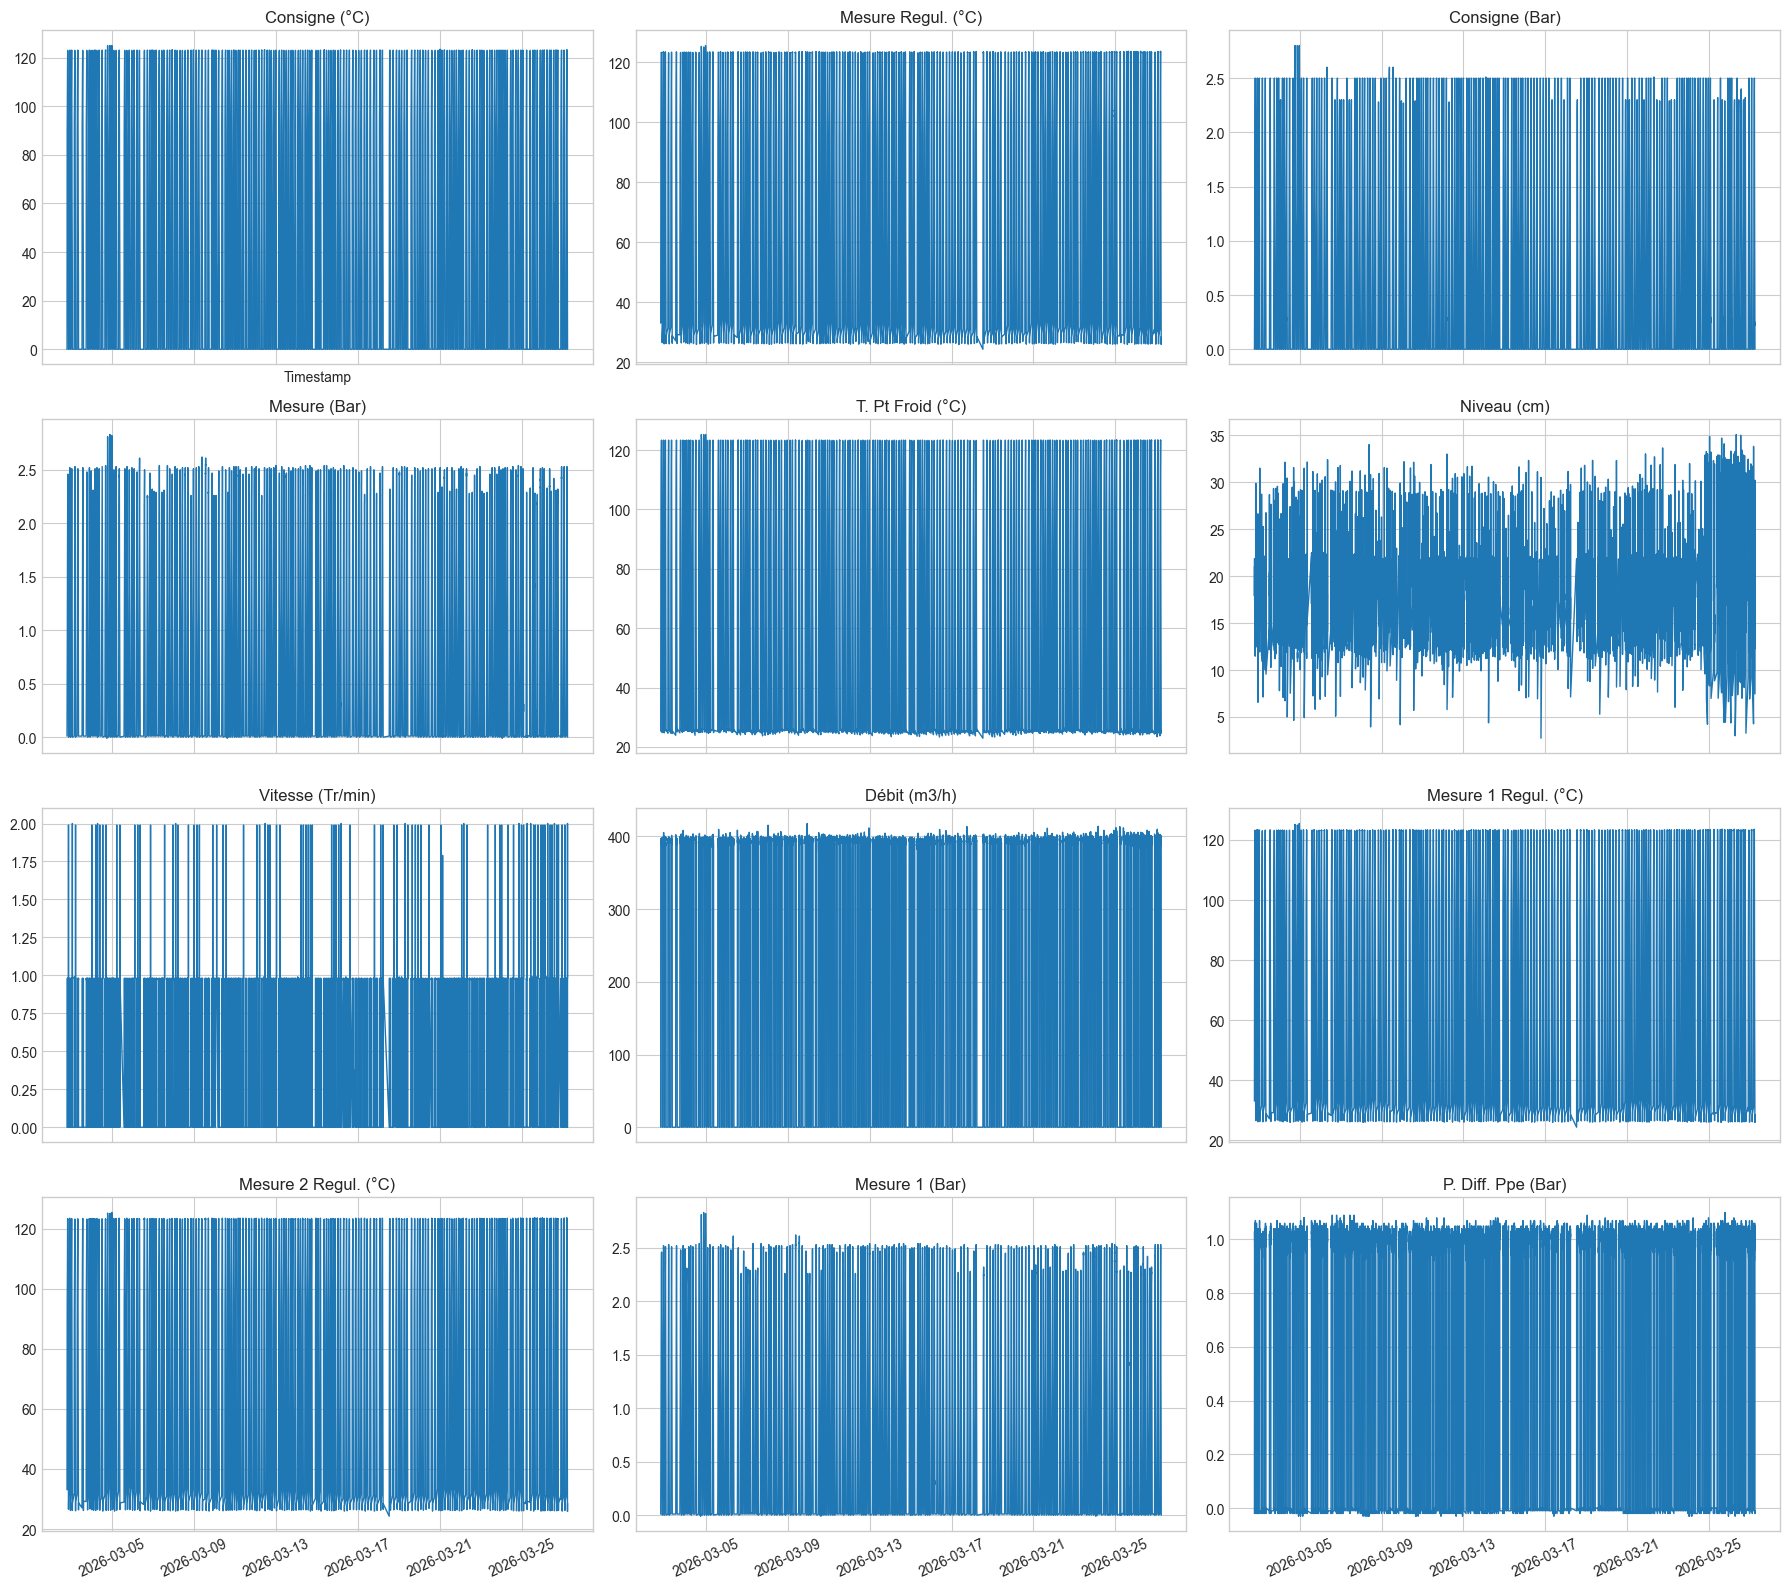

In [ ]:
# Cell comment: Build a time axis and generate small-multiple time-series plots for top numeric variables.
time_axis = df_all["Timestamp"]
plot_df = df_all.copy()
plot_df[time_axis.name] = time_axis

numeric_cols = [
    c
    for c in plot_df.columns
    if pd.api.types.is_numeric_dtype(plot_df[c]) and c not in {time_axis.name}
]

if not numeric_cols:
    raise ValueError("No numeric columns found to plot.")

ranked = sorted(numeric_cols, key=lambda c: plot_df[c].notna().sum(), reverse=True)
top_cols = ranked[:12]

n = len(top_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), sharex=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, col in enumerate(top_cols):
    ax = axes[i]
    ax.plot(plot_df[time_axis.name], plot_df[col], linewidth=1)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=25)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

axes[0].set_xlabel(time_axis.name)
plt.tight_layout()
plt.show()

In [10]:
# temp: check why the signal goes backwards

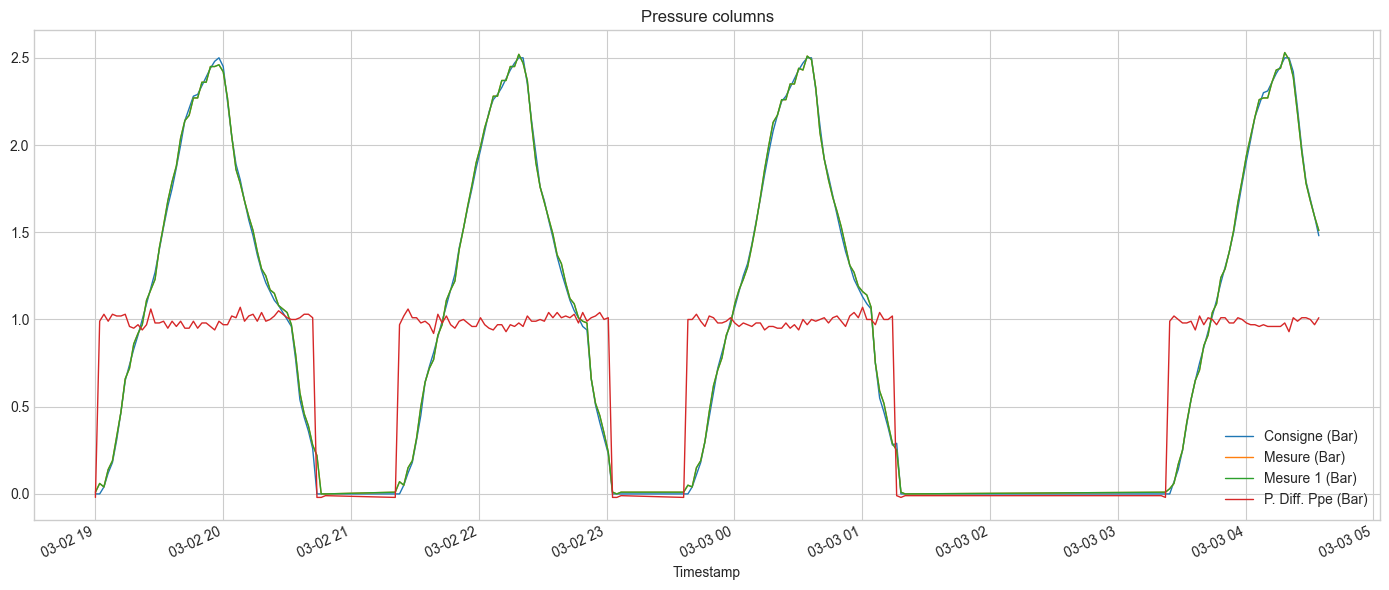

In [11]:
# Plot together similar elements

# Pressure
pressure_cols = [
    "Consigne (Bar)",
    "Mesure (Bar)",
    "Mesure 1 (Bar)",
    "P. Diff. Ppe (Bar)",
]
ax = df_all[:200].plot(time_axis.name, y=pressure_cols, figsize=(14, 6), linewidth=1)
ax.set_title("Pressure columns")
ax.set_xlabel(time_axis.name)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

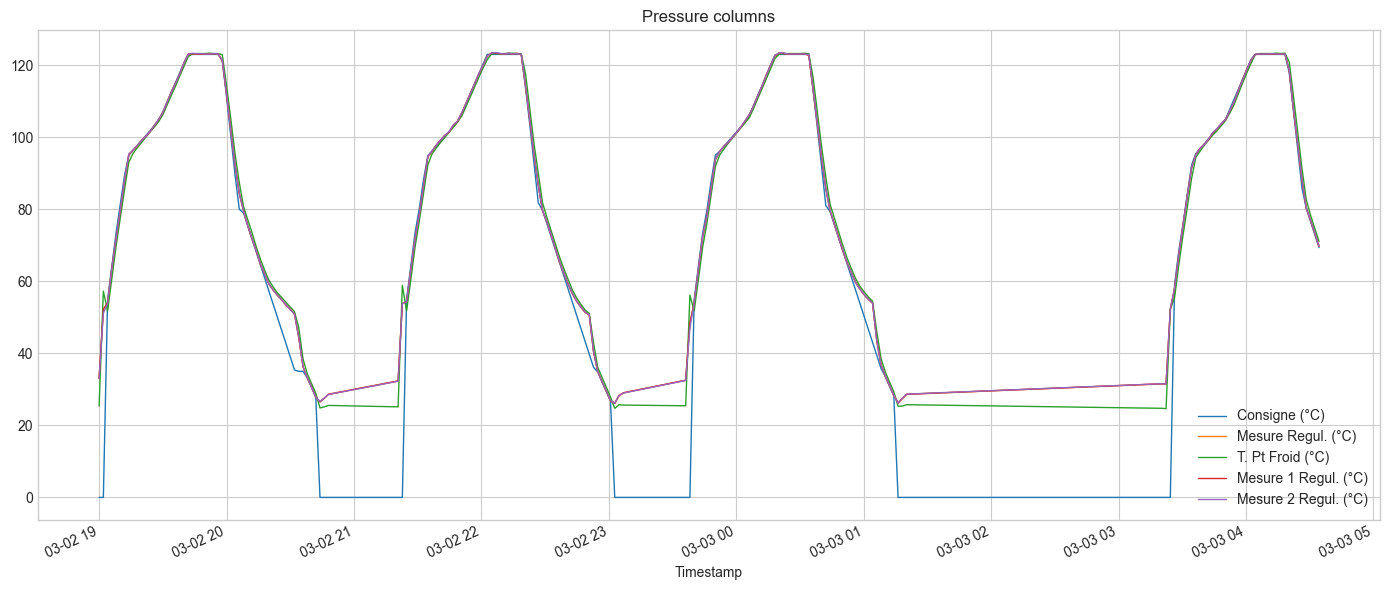

In [12]:
# Plot together similar elements

# Temperature
temperature_cols = [
    "Consigne (°C)",
    "Mesure Regul. (°C)",
    "T. Pt Froid (°C)",
    "Mesure 1 Regul. (°C)",
    "Mesure 2 Regul. (°C)",
]
ax = df_all[:200].plot(time_axis.name, y=temperature_cols, figsize=(14, 6), linewidth=1)
ax.set_title("Pressure columns")
ax.set_xlabel(time_axis.name)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

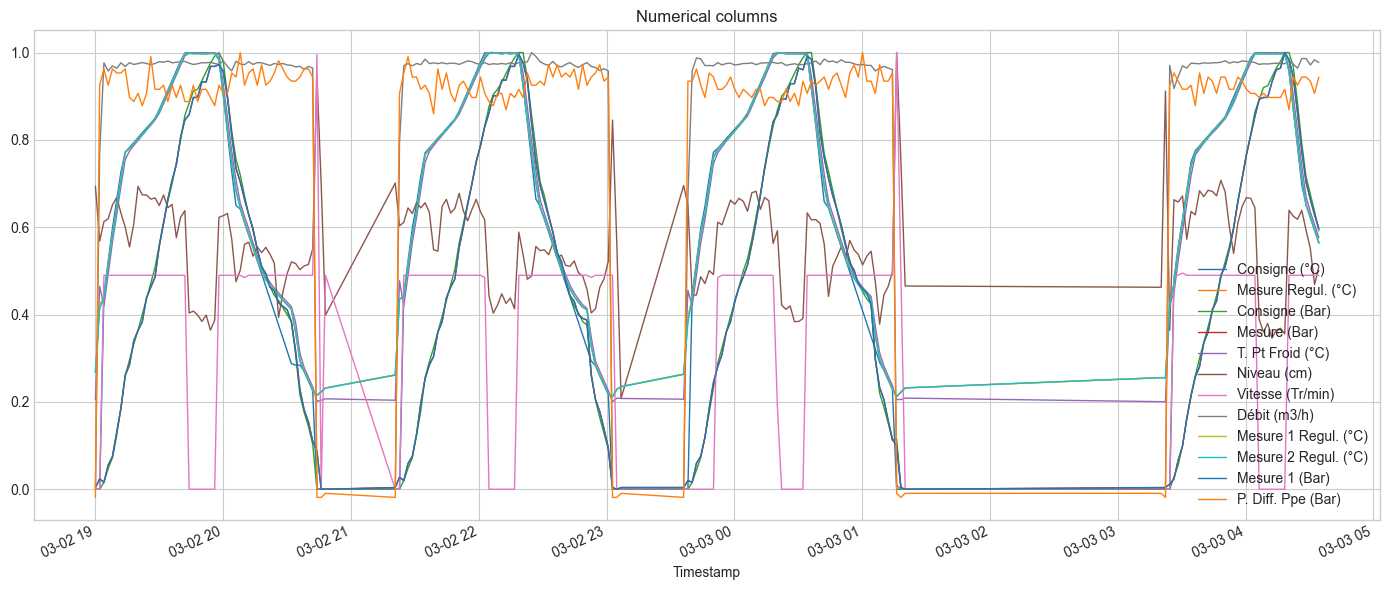

In [13]:
# One normalized plot for 4 batchs:
df_first_batchs_normalized = df_all[:200].copy()

for col in numeric_cols:
    df_first_batchs_normalized[col] = (
        df_first_batchs_normalized[col] / df_first_batchs_normalized[col].max()
    )

ax = df_first_batchs_normalized.plot(
    time_axis.name, y=numeric_cols, figsize=(14, 6), linewidth=1
)
ax.set_title("Numerical columns")
ax.set_xlabel(time_axis.name)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
# first, read steam_prod data
from src.ingest import data_workflow

list_df = []
for filename in [
    "inariz_steam_prod_2026-03-09_to_2026-03-12.csv",
    "inariz_steam_prod_2026-03-13_to_2026-03-16.csv",
]:
    df = data_workflow("inariz", "steam_prod", filename)

    # include the unit into the main column name
    df = df.rename(columns={"Valeur": "steam_production_m3_h"})

    list_df.append(df)

steam_prod = pd.concat(list_df, ignore_index=True)

In [16]:
steam_prod

,measured_at_utc,steam_production_m3_h,Unité,measured_at (local time),source_timezone
0,2026-03-08 23:00:00+00:00,644.810547,m3/h,2026-03-09 00:00:00+01:00,Europe/Paris
1,2026-03-08 23:00:01+00:00,753.914246,m3/h,2026-03-09 00:00:01+01:00,Europe/Paris
2,2026-03-08 23:00:03.002000+00:00,863.371460,m3/h,2026-03-09 00:00:03.002000+01:00,Europe/Paris
3,2026-03-08 23:00:13.003000+00:00,757.735962,m3/h,2026-03-09 00:00:13.003000+01:00,Europe/Paris
4,2026-03-08 23:00:17.007000+00:00,654.841614,m3/h,2026-03-09 00:00:17.007000+01:00,Europe/Paris
...,...,...,...,...,...
56781,2026-03-16 22:56:54.011000+00:00,109.023735,m3/h,2026-03-16 23:56:54.011000+01:00,Europe/Paris
56782,2026-03-16 22:57:33.007000+00:00,8.775745,m3/h,2026-03-16 23:57:33.007000+01:00,Europe/Paris
56783,2026-03-16 22:57:55.001000+00:00,113.669388,m3/h,2026-03-16 23:57:55.001000+01:00,Europe/Paris
56784,2026-03-16 22:58:28.014000+00:00,13.298413,m3/h,2026-03-16 23:58:28.014000+01:00,Europe/Paris


<>:19: SyntaxWarning: invalid escape sequence '\i'
<>:19: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_35244\818749728.py:19: SyntaxWarning: invalid escape sequence '\i'
  path = f"data\inariz\intermediary\Planning week 11 V14 LAM (PLANNING)  _autoclave_{ind}_inariz.csv"


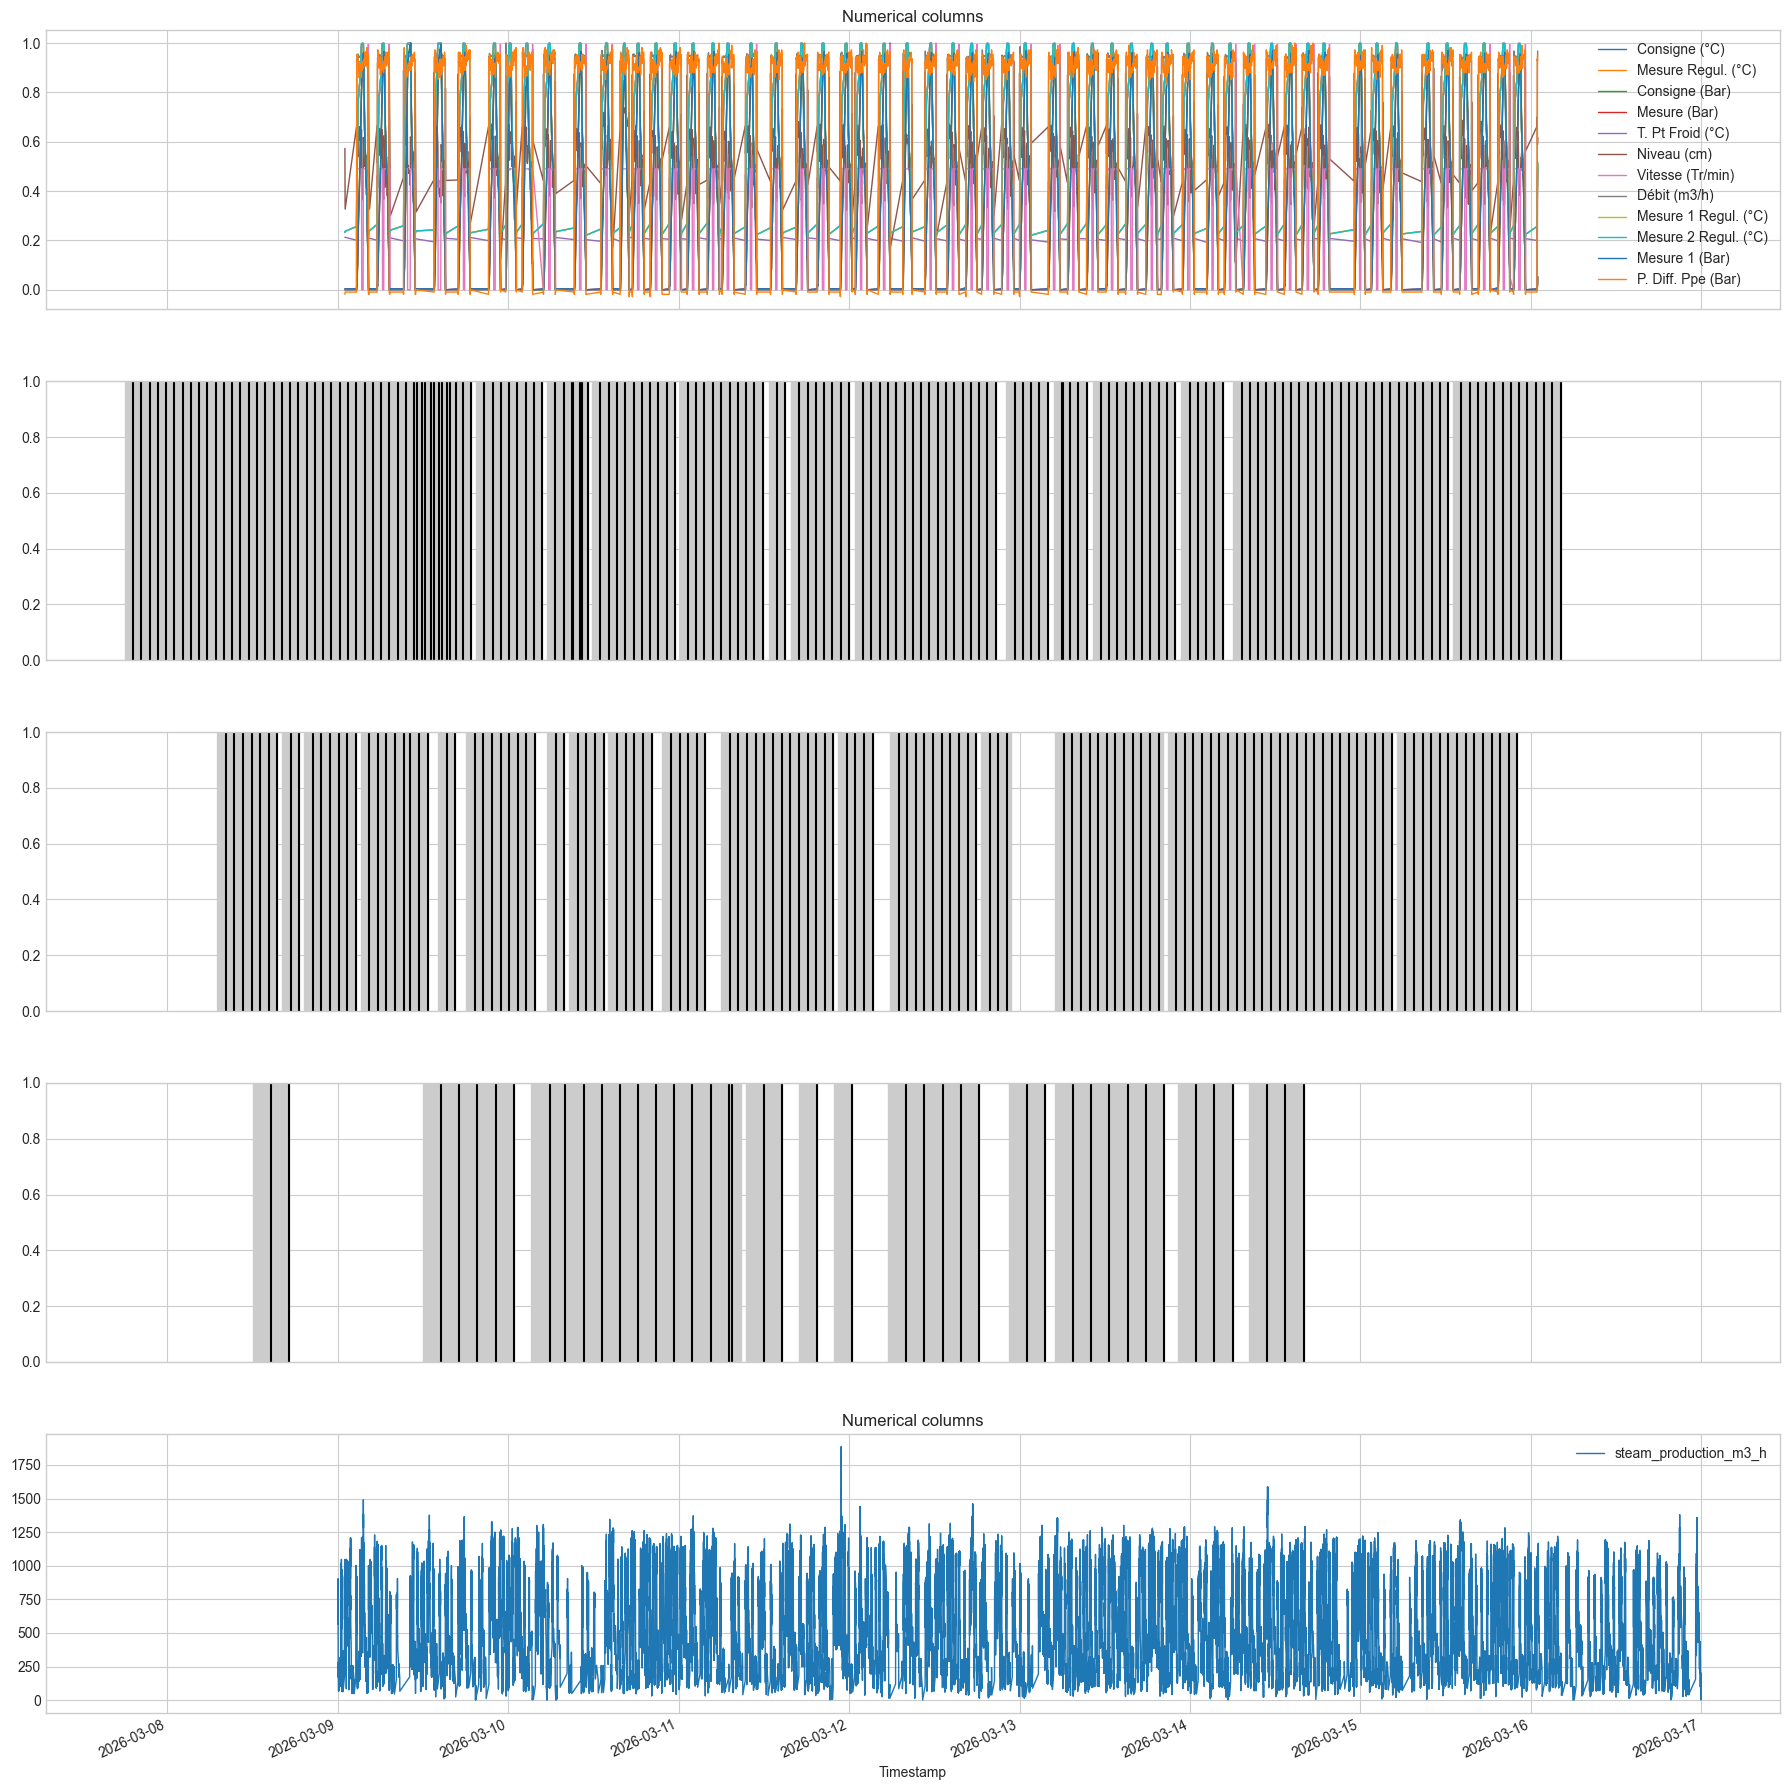

In [ ]:
# One normalized plot for one week:
time_mask = (df_all["Timestamp"] >= pd.Timestamp(2026, 3, 9, 0, 0, 0)) & (
    df_all["Timestamp"] < pd.Timestamp(2026, 3, 16, 0, 0, 0)
)
df_week_11_batchs_normalized = df_all[time_mask].copy()

for col in numeric_cols:
    df_week_11_batchs_normalized[col] = (
        df_week_11_batchs_normalized[col] / df_week_11_batchs_normalized[col].max()
    )

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(18, 6 * 3), sharex=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

# steriflow
ax = axes[0]
ax = df_week_11_batchs_normalized.plot(
    time_axis.name, y=numeric_cols, linewidth=1, ax=ax
)
ax.set_title("Numerical columns")
ax.set_xlabel(time_axis.name)

# planning # en blanc resteront les temps de nettoyage
for ind in range(1, 4):
    path = f"data\inariz\intermediary\Planning week 11 V14 LAM (PLANNING)  _autoclave_{ind}_inariz.csv"
    planning = pd.read_csv(path, sep=";")
    planning["temps_unitaire"] = (
        pd.to_timedelta(planning["temps de production"])
        / planning["QUANTITE (en autoclaves)"]
    )  # todo, un jour, prendre en compte les quantités en .5

    ax = axes[ind]
    for index, row in planning[:-1].iterrows():  # do not take last line, without data
        # grey zone
        ax.axvspan(
            pd.to_datetime(row["timestamp (local time)"]),
            pd.to_datetime(row["timestamp (local time)"])
            + pd.to_timedelta(row["temps de production"]),
            color="0.8",
        )  # light grey
        # black separators
        for i in range(int(row["QUANTITE (en autoclaves)"])):
            # print((row["timestamp (local time)"]))
            # print(type((row["timestamp (local time)"])))
            # print(planning["temps_unitaire"].iloc[0]*(1+i))
            # print(type(planning["temps_unitaire"].iloc[0]*(1+i)))
            # print(pd.to_datetime(row["timestamp (local time)"])+row["temps_unitaire"]*(1+i))
            ax.axvline(
                pd.to_datetime(row["timestamp (local time)"])
                + row["temps_unitaire"] * (1 + i),
                color="0",
            )  # black


# boiler box
ax = axes[4]
ax = steam_prod.plot("measured_at_utc", y="steam_production_m3_h", linewidth=1, ax=ax)
ax.set_title("Numerical columns")
ax.set_xlabel(time_axis.name)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

> Comment: Introduces a focused deep dive on one selected sterilization batch.

## Optional: focus on one batch

Use this section to inspect one sterilization run in detail.


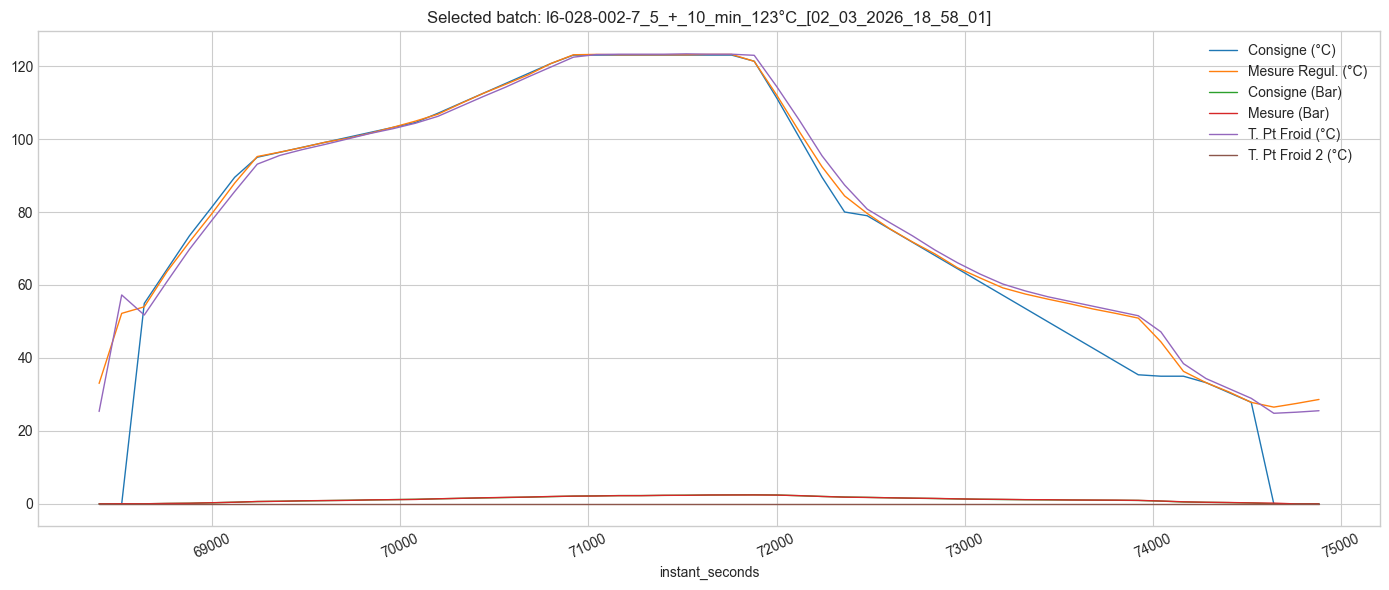

,Instant,Phase,Consigne (°C),Mesure Regul. (°C),Consigne (Bar),Mesure (Bar),T. Pt Froid (°C),T. Pt Froid 2 (°C),Niveau (cm),T. Ballast (°C),Vitesse (Tr/min),Débit (m3/h),Déflexion (mm),batch_datetime,batch_key,Mesure 1 Regul. (°C),Mesure 2 Regul. (°C),Mesure 1 (Bar),Mesure 2 (Bar),D. Pied Av. (mm),D. Pied Ar. (mm),Vol. Eau (l/h),Puiss. Elec. (kW),P. Diff. Ppe (Bar),source_file,file_mtime,file_variant,instant_seconds
0,19:00:01,0,0.00,33.03,0.00,0.01,25.34,0.0,21.88,0.0,0.00,0.11,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,33.03,33.07,0.01,0.0,0.0,0.0,0.0,0.0,-0.02,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,68401.0
1,19:02:01,0,0.00,52.22,0.00,0.06,57.27,0.0,17.91,0.0,0.00,311.82,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,52.22,51.16,0.06,0.0,0.0,0.0,0.0,0.0,0.99,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,68521.0
2,19:04:01,1,54.95,54.02,0.04,0.04,51.77,0.0,19.32,0.0,0.98,395.79,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,54.02,53.96,0.04,0.0,0.0,0.0,0.0,0.0,1.03,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,68641.0
3,19:06:01,1,64.22,63.62,0.12,0.14,60.88,0.0,19.52,0.0,0.98,388.22,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,63.62,63.65,0.14,0.0,0.0,0.0,0.0,0.0,0.99,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,68761.0
4,19:08:01,1,73.49,71.81,0.18,0.19,69.78,0.0,20.53,0.0,0.98,392.98,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,71.81,71.75,0.19,0.0,0.0,0.0,0.0,0.0,1.03,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,68881.0
5,19:10:01,2,81.43,79.61,0.31,0.33,77.79,0.0,21.05,0.0,0.98,390.66,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,79.61,79.64,0.33,0.0,0.0,0.0,0.0,0.0,1.02,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,69001.0
6,19:12:01,2,89.50,87.91,0.47,0.47,85.60,0.0,19.93,0.0,0.98,395.79,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,87.91,88.04,0.47,0.0,0.0,0.0,0.0,0.0,1.02,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,69121.0
7,19:14:01,3,95.01,95.20,0.65,0.66,93.11,0.0,18.91,0.0,0.98,392.37,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,95.20,95.33,0.66,0.0,0.0,0.0,0.0,0.0,1.03,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,69241.0
8,19:16:01,3,96.37,96.40,0.74,0.72,95.51,0.0,17.49,0.0,0.98,395.91,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,96.40,96.43,0.72,0.0,0.0,0.0,0.0,0.0,0.96,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,69361.0
9,19:18:01,3,97.73,97.70,0.83,0.86,97.11,0.0,19.15,0.0,0.98,394.32,0.0,2026-03-02 18:58:01,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,97.70,97.73,0.86,0.0,0.0,0.0,0.0,0.0,0.95,l6-028-002-7_5_+_10_min_123°C_[02_03_2026_18_5...,2026-03-02 19:49:32.513788223,merged,69481.0


In [ ]:
# Cell comment: Filter one batch, build its time axis, and plot a detailed subset of numeric signals.
selected_batch = df_all["batch_key"].dropna().iloc[0] if not df_all.empty else None
batch_df = (
    df_all[df_all["batch_key"] == selected_batch].copy()
    if selected_batch is not None
    else pd.DataFrame()
)

if batch_df.empty:
    print("No batch available.")
else:
    t = df_all["Timestamp"]
    batch_df[t.name] = t
    batch_num = [
        c
        for c in batch_df.columns
        if pd.api.types.is_numeric_dtype(batch_df[c]) and c != t.name
    ]
    keep = batch_num[:6]
    if not keep:
        print("Selected batch has no numeric columns to plot.")
    else:
        ax = batch_df.plot(x=t.name, y=keep, figsize=(14, 6), linewidth=1)
        ax.set_title(f"Selected batch: {selected_batch}")
        ax.set_xlabel(t.name)
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

    display(batch_df.head(10))

> Comment: Captures key implementation notes and assumptions for future reuse.

## Notes

- The `activity_flags` dataframe preserves line-12 active/inactive state per file and column.
- `df_all` keeps `batch_datetime` extracted from `[dd_mm_YYYY_HH_MM_SS]` in filenames.
- Base and `_II` files are merged by `Instant`, `Phase`, `batch_key`, and `batch_datetime`.
